In [1]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

INPUT_FILE  = "bank_transactions.csv"
OUTPUT_FILE = "financecore_clean.csv"
DECISIONS   = []

def log(msg: str):
    DECISIONS.append(msg)
    print(f"  ✔  {msg}")

sns.set_theme(style="whitegrid")

In [2]:
df = pd.read_csv(INPUT_FILE, low_memory=False)
print(f"Shape: {df.shape}")
df.head()

Shape: (2060, 16)


,transaction_id,client_id,date_transaction,montant,devise,taux_change_eur,montant_eur,categorie,produit,agence,type_operation,statut,score_credit_client,segment_client,solde_avant,taux_interet
0,TXN000559,CLI0060,2022-04-19 02:31:00,2050.42,EUR,1.00,2050.42,Depot especes,Compte Epargne,Marseille-Vieux-Port,Credit,Complete,NaN,Premium,16415.1,NaN
1,TXN001154,CLI0057,2024-06-20 20:51:00,-123.66,GBP,0.86,-143.79,Retrait DAB,Credit Consommation,NaN,Debit,Rejete,435.0,Risque,42890.81,NaN
2,TXN000764,CLI0015,2024-08-28 05:03:00,-396.17,EUR,1.00,-396.17,Prelevement,PEA,Lyon-Part-Dieu,Debit,Complete,648.0,Standard,48489.38,NaN
3,TXN001598,CLI0045,2024-01-07 08:16:00,225.2,EUR,1.00,225.20,Paiement CB,Credit Consommation,Bordeaux-Meriadeck,Credit,Complete,704.0,Standard,43962.51,NaN
4,TXN001873,CLI0034,2024-08-11 19:52:00,935.32,EUR,1.00,935.32,Interets,Credit Immobilier,Bordeaux-Meriadeck,Credit,Complete,457.0,Risque,17312.83,NaN


In [3]:
df.dtypes

transaction_id          object
client_id               object
date_transaction        object
montant                 object
devise                  object
taux_change_eur        float64
montant_eur            float64
categorie               object
produit                 object
agence                  object
type_operation          object
statut                  object
score_credit_client    float64
segment_client          object
solde_avant             object
taux_interet           float64
dtype: object

In [4]:
df.describe(include='all')

,transaction_id,client_id,date_transaction,montant,devise,taux_change_eur,montant_eur,categorie,produit,agence,type_operation,statut,score_credit_client,segment_client,solde_avant,taux_interet
count,2060,2060,2060,2060,2060,2060.000000,2060.000000,2060,2060,1996,2060,2060,1893.000000,1955,2060,0.0
unique,2000,150,2058,1974,9,NaN,NaN,8,8,16,2,3,NaN,6,2000,NaN
top,TXN000611,CLI0096,2024-12-20 09:21:00,0.0,EUR,NaN,NaN,Prelevement,Compte Epargne,Bordeaux-Meriadeck,Debit,Complete,NaN,Standard,20709.67,NaN
freq,2,22,2,10,1351,NaN,NaN,313,281,351,1073,1781,NaN,1115,2,NaN
mean,NaN,NaN,NaN,NaN,NaN,1.534782,-116.223170,NaN,NaN,NaN,NaN,NaN,627.866350,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,2.234708,2083.777234,NaN,NaN,NaN,NaN,NaN,132.193879,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,0.860000,-8705.810000,NaN,NaN,NaN,NaN,NaN,-100.000000,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,1.000000,-1218.870000,NaN,NaN,NaN,NaN,NaN,586.000000,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,1.000000,-60.405000,NaN,NaN,NaN,NaN,NaN,643.000000,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,1.000000,957.805000,NaN,NaN,NaN,NaN,NaN,701.000000,NaN,NaN,NaN


taux_interet           100.00
score_credit_client      8.11
segment_client           5.10
agence                   3.11
dtype: float64


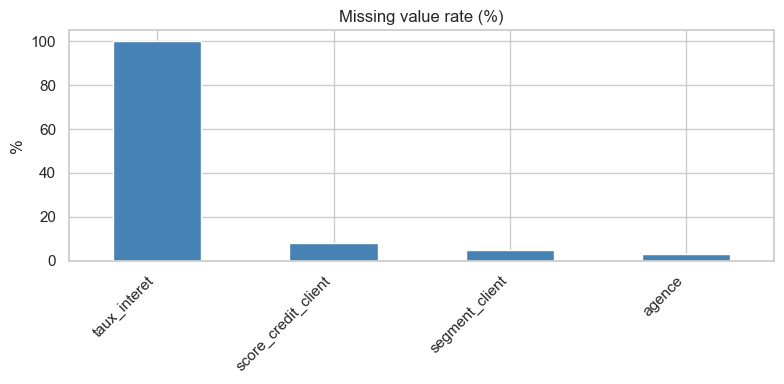

In [5]:
missing = df.isnull().mean().mul(100).round(2).sort_values(ascending=False)
missing_nonzero = missing[missing > 0]
print(missing_nonzero)

fig, ax = plt.subplots(figsize=(8, 4))
missing_nonzero.plot(kind="bar", ax=ax, color="steelblue")
ax.set_title("Missing value rate (%)")
ax.set_ylabel("%")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [6]:
dup_count = df.duplicated(subset=["transaction_id"]).sum()
print(f"Duplicate transaction_ids: {dup_count}")

if dup_count > 0:
    dupes = df[df.duplicated(subset=["transaction_id"], keep=False)]
    print(dupes.sort_values("transaction_id").head(6))

Duplicate transaction_ids: 60
     transaction_id client_id     date_transaction   montant devise  \
750       TXN000034   CLI0099  2024-02-21 18:22:00       0.0    EUR   
1379      TXN000034   CLI0099  2024-02-21 18:22:03    1745.7    EUR   
1128      TXN000052   CLI0076     31/05/2024 03:50   2120.25    EUR   
394       TXN000052   CLI0076  2024-05-31 03:50:03   2120.25    EUR   
14        TXN000116   CLI0077  2024-11-09 17:31:03  -5728.17    EUR   
112       TXN000116   CLI0077  2024-11-09 17:31:00  -5728.17    EUR   

      taux_change_eur  montant_eur               categorie  \
750               1.0      1745.70                Interets   
1379              1.0      1745.70                Interets   
1128              1.0      2120.25                Interets   
394               1.0      2120.25                Interets   
14                1.0     -5728.17  Virement international   
112               1.0     -5728.17  Virement international   

                  produit           a

In [7]:
before = len(df)
df = df.drop_duplicates(subset=["transaction_id"], keep="first")
log(f"Removed {before - len(df)} duplicate rows")

  ✔  Removed 60 duplicate rows


In [8]:
def parse_date(val):
    if pd.isnull(val):
        return pd.NaT
    val = str(val).strip()
    for fmt in ("%d/%m/%Y %H:%M:%S", "%d/%m/%Y", "%Y-%m-%d %H:%M:%S", "%Y-%m-%d"):
        try:
            return datetime.strptime(val, fmt)
        except ValueError:
            continue
    return pd.NaT

df["date_transaction"] = df["date_transaction"].apply(parse_date)
null_dates = df["date_transaction"].isnull().sum()
log(f"Unified date_transaction to datetime; {null_dates} unparseable → NaT")

  ✔  Unified date_transaction to datetime; 75 unparseable → NaT


In [9]:
df["montant"] = (
    df["montant"].astype(str)
                 .str.replace(",", ".", regex=False)
                 .str.strip()
)
df["montant"] = pd.to_numeric(df["montant"], errors="coerce")
log("Fixed montant decimal separator → float")

  ✔  Fixed montant decimal separator → float


In [10]:
df["solde_avant"] = (
    df["solde_avant"].astype(str)
                     .str.replace(r"[Ee][Uu][Rr]", "", regex=True)
                     .str.strip()
)
df["solde_avant"] = pd.to_numeric(df["solde_avant"], errors="coerce")
log("Stripped EUR suffix from solde_avant → float")

  ✔  Stripped EUR suffix from solde_avant → float


In [11]:
df["devise"] = df["devise"].astype(str).str.upper().str.strip()
df["segment_client"] = df["segment_client"].astype(str).str.strip().str.title()
df["agence"] = df["agence"].astype(str).str.strip()
df["agence"] = df["agence"].apply(lambda x: re.sub(r"\s+", " ", x))
log("Normalized devise, segment_client, agence")

  ✔  Normalized devise, segment_client, agence


In [12]:
median_score = df["score_credit_client"].median()
missing_score = df["score_credit_client"].isnull().sum()
df["score_credit_client"] = df["score_credit_client"].fillna(median_score)
log(f"Imputed {missing_score} missing score_credit_client with median ({median_score:.0f})")

mode_seg = df["segment_client"].mode()[0]
missing_seg = (df["segment_client"].isnull() | (df["segment_client"] == "Nan")).sum()
df["segment_client"] = df["segment_client"].replace("Nan", np.nan).fillna(mode_seg)
log(f"Imputed {missing_seg} missing segment_client with mode ('{mode_seg}')")

mode_agence = df["agence"].mode()[0]
missing_agence = (df["agence"].isnull() | (df["agence"] == "Nan")).sum()
df["agence"] = df["agence"].replace("Nan", np.nan).fillna(mode_agence)
log(f"Imputed {missing_agence} missing agence with mode ('{mode_agence}')")

for col in ["montant", "solde_avant", "taux_change_eur", "montant_eur", "taux_interet"]:
    missing_n = df[col].isnull().sum()
    if missing_n > 0:
        med = df[col].median()
        df[col] = df[col].fillna(med)
        log(f"Imputed {missing_n} missing {col} with median ({med:.4f})")

df.isnull().sum()[df.isnull().sum() > 0]

  ✔  Imputed 160 missing score_credit_client with median (645)
  ✔  Imputed 100 missing segment_client with mode ('Standard')
  ✔  Imputed 0 missing agence with mode ('Bordeaux-Meriadeck')
  ✔  Imputed 2000 missing taux_interet with median (nan)


c:\Users\anwar\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1241: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)


date_transaction      75
taux_interet        2000
dtype: int64

  ✔  Flagged 108 outliers in montant via IQR


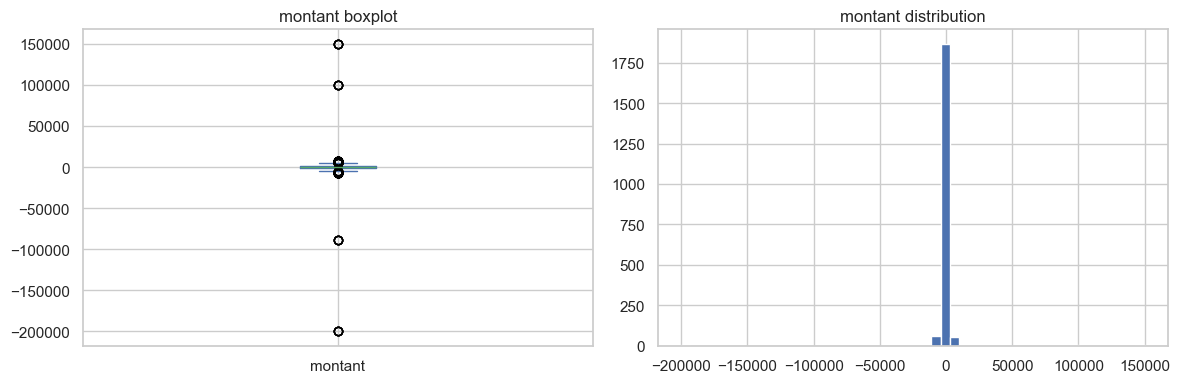

In [13]:
df["is_anomaly"] = False

def flag_iqr(series, factor=1.5):
    Q1, Q3 = series.quantile(0.25), series.quantile(0.75)
    IQR = Q3 - Q1
    return (series < Q1 - factor * IQR) | (series > Q3 + factor * IQR)

anomaly_montant = flag_iqr(df["montant"])
df.loc[anomaly_montant, "is_anomaly"] = True
log(f"Flagged {anomaly_montant.sum()} outliers in montant via IQR")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df["montant"].plot(kind="box", ax=axes[0], title="montant boxplot")
df["montant"].hist(bins=50, ax=axes[1])
axes[1].set_title("montant distribution")
plt.tight_layout()
plt.show()

In [14]:
anomaly_score = (df["score_credit_client"] < 0) | (df["score_credit_client"] > 850)
df.loc[anomaly_score, "is_anomaly"] = True
log(f"Flagged {anomaly_score.sum()} rows with credit score outside [0, 850]")
print(f"Total anomalies flagged: {df['is_anomaly'].sum()}")

  ✔  Flagged 4 rows with credit score outside [0, 850]
Total anomalies flagged: 112


In [15]:
df["year"]        = df["date_transaction"].dt.year
df["month"]       = df["date_transaction"].dt.month
df["quarter"]     = df["date_transaction"].dt.quarter
df["day_of_week"] = df["date_transaction"].dt.day_name()
df[["date_transaction","year","month","quarter","day_of_week"]].head(3)

,date_transaction,year,month,quarter,day_of_week
0,2022-04-19 02:31:00,2022.0,4.0,2.0,Tuesday
1,2024-06-20 20:51:00,2024.0,6.0,2.0,Thursday
2,2024-08-28 05:03:00,2024.0,8.0,3.0,Wednesday


In [16]:
df["montant_eur_verified"] = np.where(
    df["taux_change_eur"] != 0,
    df["montant"] / df["taux_change_eur"],
    np.nan
)
df["montant_eur_diff"] = (df["montant_eur_verified"] - df["montant_eur"]).round(4)
df[["montant","taux_change_eur","montant_eur","montant_eur_verified","montant_eur_diff"]].head(5)

,montant,taux_change_eur,montant_eur,montant_eur_verified,montant_eur_diff
0,2050.42,1.00,2050.42,2050.420000,0.0000
1,-123.66,0.86,-143.79,-143.790698,-0.0007
2,-396.17,1.00,-396.17,-396.170000,0.0000
3,225.20,1.00,225.20,225.200000,0.0000
4,935.32,1.00,935.32,935.320000,0.0000


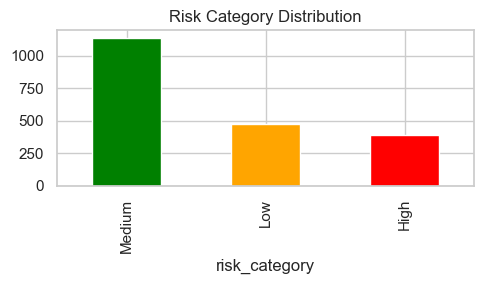

In [17]:
def credit_risk(score):
    if score >= 700: return "Low"
    if score >= 580: return "Medium"
    return "High"

df["risk_category"] = df["score_credit_client"].apply(credit_risk)

fig, ax = plt.subplots(figsize=(5, 3))
df["risk_category"].value_counts().plot(kind="bar", ax=ax, color=["green","orange","red"])
ax.set_title("Risk Category Distribution")
plt.tight_layout()
plt.show()

In [18]:
df["montant_signed"] = np.where(
    df["type_operation"].str.lower() == "credit",
    df["montant_eur"],
    -df["montant_eur"]
)
net_balance = df.groupby("client_id")["montant_signed"].sum().rename("net_balance_eur")
df = df.merge(net_balance, on="client_id", how="left")
df[["client_id","net_balance_eur"]].drop_duplicates().head(5)

,client_id,net_balance_eur
0,CLI0060,19623.23
1,CLI0057,5943.66
2,CLI0015,10794.86
3,CLI0045,21665.30
4,CLI0034,9882.58


In [19]:
client_agg = df.groupby("client_id").agg(
    nb_transactions      = ("transaction_id", "count"),
    avg_montant_eur      = ("montant_eur", "mean"),
    nb_produits_distinct = ("produit", "nunique")
).reset_index()
df = df.merge(client_agg, on="client_id", how="left")
client_agg.head(5)

,client_id,nb_transactions,avg_montant_eur,nb_produits_distinct
0,CLI0001,14,36.245000,6
1,CLI0002,12,-407.733333,6
2,CLI0003,13,-820.701538,7
3,CLI0004,16,-69.614375,7
4,CLI0005,9,-510.080000,6


In [20]:
rejection = df.copy()
rejection["is_rejected"] = rejection["statut"].str.lower().str.contains("rejet", na=False)
agency_rejection = (
    rejection.groupby("agence")["is_rejected"]
             .mean()
             .rename("rejection_rate_agence")
             .reset_index()
)
df = df.merge(agency_rejection, on="agence", how="left")
df.drop(columns=["montant_signed"], inplace=True)
agency_rejection.sort_values("rejection_rate_agence", ascending=False).head(8)

,agence,rejection_rate_agence
4,Nantes-Commerce,0.085000
5,Nice-Massena,0.076336
7,Toulouse-Capitole,0.068063
6,Paris-Centre,0.065789
3,Marseille-Vieux-Port,0.055728
8,nan,0.050000
0,Bordeaux-Meriadeck,0.045198
1,Lille-Grand-Place,0.042056


In [21]:
critical_cols = ["transaction_id","client_id","date_transaction","montant","montant_eur"]
print(df[critical_cols].isnull().sum())
print(f"Final shape: {df.shape}")

transaction_id       0
client_id            0
date_transaction    75
montant              0
montant_eur          0
dtype: int64
Final shape: (2000, 29)


In [22]:
df.to_csv(OUTPUT_FILE, index=False)
print(f"✔  Exported → {OUTPUT_FILE}")

✔  Exported → financecore_clean.csv
